# Лекция.  Нормализация и кодирование данных

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

Помните наш первый модуль, где мы с упоением чистили данные, выкидывали пропуски, рисовали гистограммы и наивно полагали, что главное — это просто вставить данные в презентацию? Так вот, хочу вас огорчить: мы были неправы. Точнее, не совсем правы. Предварительная обработка — это не ритуал «сделай красиво перед подачей». Это стратегический этап, от которого зависит, увидит ли модель то, что вы хотите ей показать. 

Сегодня мы посмотрим на предобработку как на инструмент, который может как спасти, так и убить вашу модель. Поехали.

## § 1. Нормализация

Модели понимают только числа. Это, с одной стороны, удобно (цифры — язык вселенной), а с другой — создаёт нам две проблемы. Вторая проблема появится во второй части лекции, когда мы будем кодировать категории — но это позже. Сначала — первая проблема.

Первая проблема звучит так: мало того, что данные числовые, так они ещё и живут, как правило, в принципиально разных масштабах. Представьте себе, что один ваш признак — это количество купленных вами бананов в ближайшей «Пятерочке» (штуки, единицы, скромно), а второй — ваш годовой доход, о котором вы гворите своей подружке, а это, разумеется, миллионы (и не рублей), у вас же яхты, элитный клуб, и вообще: у вас всё серьёзно. Для человека разница очевидна, для модели — нет. Модель, коллеги, не понимает контекста. Она послушно загрузит числа в матричное уравнение, посчитает коэффициенты и обнаружит, что доход влияет на предсказание благосклонности вашей подружки в миллион раз сильнее, чем количество бананов. Это не потому что модель глупая. Это потому что мы не предупредили её, что масштабы разные.

Здесь и возникает нормализация: **приведение признаков к единому масштабу**. Звучит как магия, но на деле — ничего особенного, простая арифметика. Важно понимать: нормализация не добавляет информации, не исправляет кривые распределения, не делает из плохих данных хорошие. Она всего лишь говорит модели: «Эти два столбца измеряются в разных единицах, но по сути они равноправны. Относись к ним одинаково». 

Нормализации бывают разные, при этом не бывает одной единственной «правильной» нормализации. Минимакс, стандартизация, робастная нормализация — это не заклинания из мира статистики, а разные философии. В одной мы сжимаем данные в промежуток от нуля до единицы, в другой — вычитаем среднее и делим на стандартное отклонение, в третьей — опираемся на медианы. Каждая из них хороша в своём контексте, и мы с вами разберём их достаточно подробно. 

Потому что выбрать неправильную нормализацию — это как надеть лыжи на пляже: формально — да, можно передвигаться, но удовольствия никакого (и выглядит странно).

### 1.1. Нормализация по минимаксу

Если стандартизация — это поиск баланса относительно среднего, то нормализация по минимаксу (Min-Max Scaling) — это попытка втиснуть всё живое в предсказуемый диапазон от 0 до 1. Идея предельно проста: мы вычитаем минимум и делим на размах.

Математически это выглядит так:

$$
{\rm X}_{\rm norm} = \frac{{\rm X} - {\rm X}_{\rm min}}{{\rm X}_{\rm max} - {\rm X}_{\rm min}}
$$

В scikit-learn этот инструмент представлен классом MinMaxScaler. И если вы проделаете этот фокус вручную на numpy и сравните результат с `scaler.fit_transform()`, вы получите идентичные массивы. Если нет — вы где-то ошиблись. Скорее всего, в арифметике.


Чем хороша эта нормализация? Она незаменима, когда ваши алгоритмы имеют жёсткие границы или когда для них критически важно, чтобы данные лежали строго в диапазоне. 

Чем она плоха? Она крайне чувствительна к выбросам. Если у одного вашего клиента доход — миллиард, а у остальных — средняя зарплата, то MinMaxScaler «раздавит» всех остальных в ничтожную точку, близкую к нулю. Модель не увидит разницы между нормальной зарплатой и её отсутствием. В таких случаях — когда данные загрязнены аномалиями — о минимаксе лучше забыть и подумать о более устойчивых методах.

#### Пример

Создадим небольшой искусственный датафрейм: два признака, сто точек. 

In [2]:
np.random.seed(42)
x1 = np.random.uniform(10, 110, 100)
x2 = np.random.uniform(100, 300, 100)

df = pd.DataFrame({'x1': x1, 'x2': x2})
print(df)

            x1          x2
0    47.454012  106.285837
1   105.071431  227.282082
2    83.199394  162.871196
3    69.865848  201.714138
4    25.601864  281.513295
..         ...         ...
95   59.379560  169.841915
96   62.273283  245.191136
97   52.754102  279.422052
98   12.541913  277.417285
99   20.789143  255.975109

[100 rows x 2 columns]


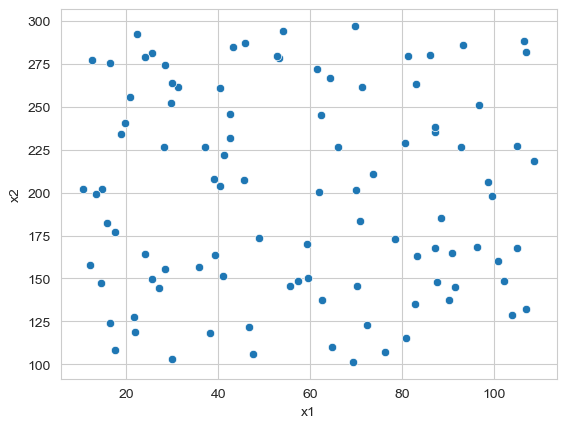

In [3]:
sns.scatterplot(data = df, x = 'x1', y = 'x2')
plt.show()

Теперь — ручная нормализация по минимаксу. Вспомним формулу, реализуем её и сохраним результат в отдельный датафрейм:

In [4]:
df_min_max_manual = (df - df.min()) / (df.max() - df.min())
print(df_min_max_manual)

          x1        x2
0   0.376025  0.025010
1   0.963140  0.643159
2   0.740267  0.314095
3   0.604399  0.512536
4   0.153354  0.920216
..       ...       ...
95  0.497545  0.349707
96  0.527032  0.734653
97  0.430033  0.909533
98  0.020275  0.899291
99  0.104313  0.789746

[100 rows x 2 columns]


Посмотрим, как выглядит облако нормализованных данных. Интересно, сможет ли кто-нибудь из вас обнаружить разницу, коллеги?

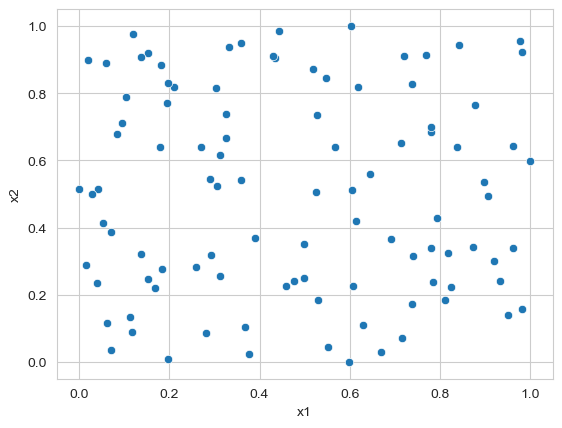

In [5]:
sns.scatterplot(data = df_min_max_manual, x = 'x1', y = 'x2')
plt.show()

Теперь — как это делает sklearn. Синтаксически это выглядит так:

In [6]:
scaler = MinMaxScaler()
scaler.fit(df)
print('')

In [7]:
df_min_max_sklearn = scaler.transform(df)
df_min_max_sklearn[:5] # Первые 5 точек

array([[0.3760253 , 0.02500981],
       [0.96314049, 0.64315864],
       [0.74026683, 0.31409459],
       [0.60439946, 0.51253645],
       [0.15335431, 0.9202165 ]])

Мы где-то это видели, не правда ли? Здесь происходит тот самый знаменитый `fit`, который путает всех новичков, и не только. 

Что такое `fit` в `MinMaxScaler`?  

Когда мы говорим `scaler.fit(df)`, объект `scaler` вычисляет и запоминает для каждого столбца минимальное и максимальное значения. Буквально: он проходит по данным, находит `min`, находит `max` и кладёт их в свои атрибуты `scaler.data_min_` и `scaler.data_max_`. Никакой магии, никакого обучения в смысле «модели». 

In [8]:
print("Минимумы :", scaler.data_min_)
print("Максимумы:", scaler.data_max_)

Минимумы : [ 10.55221171 101.39042611]
Максимумы: [108.68869366 297.13009082]


Эти атрибуты — массивы NumPy, где каждый элемент соответствует своему столбцу. Удобно? А то.

После того как `scaler`, пропущенный через метод `fit`, сохранён, мы вызываем `transform`. Он берёт эти сохранённые минимумы и максимумы и применяет к ним нашу формулу для каждого столбца: (x - min) / (max - min). Если бы мы передали в `transform` данные с другими границами, они всё равно масштабировались бы относительно старых значений. Именно так устроена нормализация новых данных после обучения: вы не пересчитываете границы заново, а используете именно те, что уже были вычислены на тренировочной выборке. И да, это имеет прямое отношение к `fit` в моделях — там то же самое: вы запоминаете параметры на трейне и применяете их на тесте, чтобы не подглядывать в будущее.

В жизни вы почти всегда будете писать сокращённо: `scaler.fit_transform(df)`. Это последовательно делает то же самое: сначала `fit` (посчитай минимумы и максимумы), потом `transform` (примени формулу). И возвращает нам NumPy-массив.

In [9]:
df_min_max_sklearn = scaler.fit_transform(df)
df_min_max_sklearn[:5]

array([[0.3760253 , 0.02500981],
       [0.96314049, 0.64315864],
       [0.74026683, 0.31409459],
       [0.60439946, 0.51253645],
       [0.15335431, 0.9202165 ]])

Теперь проверим тождественность результатов ручного расчёта и машинного. Нужно преобразовать `df_min_max_sklearn` обратно в `DataFrame` (чтобы сравнение было удобным) и вычислить разницу:

In [10]:
df_min_max_sklearn = pd.DataFrame(df_min_max_sklearn, columns=['x1', 'x2'])
difference = (df_min_max_manual - df_min_max_sklearn).abs().max()
print("Максимальное отклонение между ручной нормализацией и sklearn:")
print(difference)

Максимальное отклонение между ручной нормализацией и sklearn:
x1    3.330669e-16
x2    1.110223e-16
dtype: float64


Результат — нули (или, в худшем для вещественных чисел случае, что-то порядка 1e-15 — погрешность машинного округления). А значит, всё верно: формула работает, sklearn работает, вы всё поняли правильно. Можно идти дальше, оставив этот простой, но важный факт у себя в памяти.

### 1.2. Стандартная нормализация (стандартизация)

Если MinMaxScaler — это попытка запихнуть данные в прокрустово ложе отрезка [0, 1], то стандартизация (она же Z-score нормализация) — это философия иного рода. Мы не задаем границы данных, мы задаем центр распределения и его разброс.

Формула выглядит так:

$$
{\rm X_{\rm stand}} = \frac{{\rm X} - {\rm \mu}}{\rm \sigma}
$$

где ${\rm \mu}$ — среднее арифметическое, а ${\rm \sigma}$ — стандартное отклонение (корень из дисперсии, если кто забыл). После этого преобразования данные центрируются вокруг нуля и приобретают единичное стандартное отклонение. Можете проверить: среднее нового признака будет равно 0, а дисперсия — 1.

Стандартная нормализация не боится выбросов. Ну, не то чтобы совсем не боится — выбросы всё ещё влияют на среднее и сигму, но гораздо меньше, чем на min и max. Поэтому если в ваших данных есть аномалии, но вы не хотите с ними возиться, стандартизация будет хорошим выбором.

#### Пример
Вернемся к нашему примеру про сто точек. Мы можем выполнить стандартизацию вручную:

In [11]:
df_stand_manual = (df - df.mean()) / df.std()
print(df_stand_manual)

          x1        x2
0  -0.321493 -1.591213
1   1.615296  0.472785
2   0.880076 -0.625959
3   0.431873  0.036638
4  -1.056045  1.397881
..       ...       ...
95  0.079380 -0.507050
96  0.176652  0.778285
97 -0.143332  1.362208
98 -1.495050  1.328010
99 -1.217823  0.962242

[100 rows x 2 columns]


Еще раз нарисуем катринку и еще раз подумаем, чем она отличается от двух предыдущих:

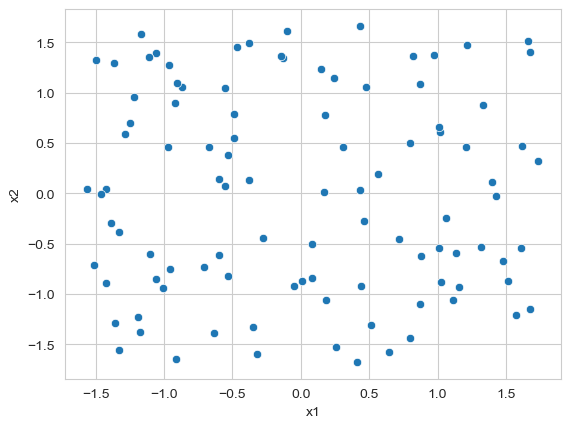

In [12]:
sns.scatterplot(data = df_stand_manual, x = 'x1', y = 'x2')
plt.show()

Разумеется, для стандартизации в sklearn имеется ровно такой же элегантный класс, как и для `MinMaxScaler`. Называется он, с некоторой долей изобретательности, `StandardScaler`. Принцип работы — один в один: вы создаёте экземпляр класса, вызываете последовательно `fit()` `transform()` (или `fit_transform()`, если вы человек торопливый и не боитесь последствий), и получаете преобразованные данные.

In [13]:
scaler = StandardScaler()
scaler.fit(df)
df_stand_sklearn = scaler.transform(df)
df_stand_sklearn[:5] # Первые 5 точек

array([[-0.32311215, -1.59922959],
       [ 1.62343393,  0.47516709],
       [ 0.88450935, -0.62911286],
       [ 0.43404902,  0.03682243],
       [-1.06136481,  1.40492361]])

Что происходит под капотом? Ровно то, что мы обсуждали: `scaler` запоминает средние и стандартные отклонения по каждому признаку, а затем применяет формулу z-нормализации. Никакой магии. Только арифметика.

После обучения `scaler`, как и положено хорошо воспитанному объекту, хранит полученные знания в своих атрибутах:

In [14]:
print("Средние:", scaler.mean_)
print("Сигмы  :", scaler.scale_)

Средние: [ 57.01807434 199.56634463]
Сигмы  : [29.59982266 58.32840279]


Откуда взялись эти числа? `scaler.mean_` — это просто среднее арифметическое по каждому столбцу. `scaler.scale_` — стандартное отклонение, причём sklearn по умолчанию считает его с делением на (n-1), давая несмещённую оценку. Не то чтобы это имело огромное значение при больших выборках, но знатоки оценят.

А теперь — внимание. Если вы мне не верите (и правильно делаете), можете проверить sklearn вручную. Честно посчитать формулу, не подглядывая в чужие реализации. И тогда вы получите… небольшую разницу.

In [15]:
df_stand_sklearn = pd.DataFrame(df_stand_sklearn, columns=['x1', 'x2'])
difference = (df_stand_manual - df_stand_sklearn).abs().max()
print("Максимальное отклонение между ручной нормализацией и sklearn:")
print(difference)

Максимальное отклонение между ручной нормализацией и sklearn:
x1    0.008750
x2    0.008437
dtype: float64


И вот тут возникает закономерный вопрос: «Позвольте, лектор, но ведь формулы одни и те же! Откуда разница? Вы нас обманываете? Вы — шарлатан?»

Нет. Я не шарлатан. Я просто умею читать документацию.

Дело в том, что sklearn использует деление на (n-1) при вычислении стандартного отклонения — выборочную, а не популяционную σ. Если вы в своей ручной формуле честно поделили на n (как это делают `np.std()` и `df.std()` по умолчанию в pandas), то получите немного другое стандартное отклонение. Сигма в sklearn будет чуть больше — потому что деление на меньшее число даёт больший результат. А значит, и нормализованные значения будут немного разными.

Насколько «немного»? Ровно на ту разницу, которую мы видим: тысячные доли для сотен объектов. А для выборки в несколько сотен тысяч точек разница будет мизерной. Оба метода дают корректную нормализацию, sklearn просто чуть более педантичен в статистических формулах, он как истинный перфекционист, предпочитает несмещённую оценку.

Если вы хотите, чтобы ручной расчёт совпадал со sklearn до пятнадцатого знака после запятой, используйте  `np.std(ddof=1)` или `df.std(ddof=1)`. И тогда разница исчезнет. Но, между нами, для практических задач машинного обучения эта разница не стоит потраченных нервов.

### 1.3. Робастная нормализация

Мы рассмотрели два подхода: один — наивный `MinMaxScaler`, который смотрит на границы данных; второй — статистический `StandardScaler`, который полагается на среднее и стандартное отклонение. Но что делать, если данные — грязные? Если в них есть выбросы, которые нагло торчат в стороне и портят всю картину?

Для таких случаев существует третий путь — робастная нормализация, устойчивая к выбросам. Она реализована в классе `RobustScaler` из того же модуля `sklearn.preprocessing`.

Формула робастной нормализации:

$$
{\rm X_{robust}} = \frac{{\rm X - med}}{\rm IQR}
$$

где ${\rm med}$ — медиана, а ${\rm IQR}$ — межквартильный размах (Interquartile Range), то есть разность между третьим и первым квартилями:

$$
{\rm IQR} = {\rm Q_3 - Q_1}
$$

Медиана и IQR являются робастными (устойчивыми) статистиками. Если у вас есть выброс, скажем, со значением 10⁹, медиана от этого не изменится, а IQR изменится крайне незначительно. Согласитесь, среднее и стандартное отклонение этим похвастаться не могут.

Вычисления вручную вполне очевидны:

In [16]:
median = df.median()
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_robust_manual = (df - median) / IQR
print(df_robust_manual)

          x1        x2
0  -0.166857 -0.904644
1   0.906089  0.249505
2   0.498790 -0.364892
3   0.250494  0.005620
4  -0.573785  0.766802
..       ...       ...
95  0.055220 -0.298400
96  0.109106  0.420335
97 -0.068159  0.746854
98 -0.816986  0.727731
99 -0.663407  0.523200

[100 rows x 2 columns]


Снова нарисуем картинку и снова попытаемся найти отличия от предыдущих графиков:

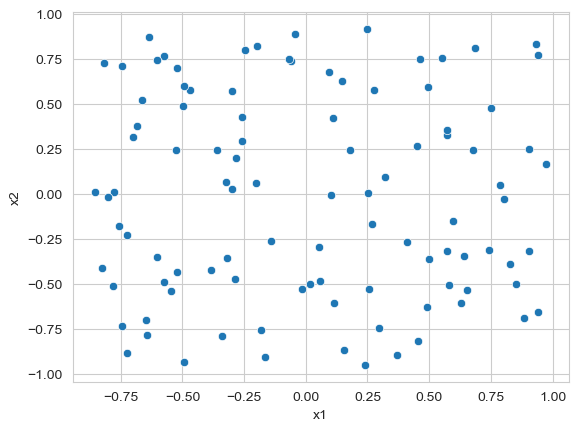

In [17]:
sns.scatterplot(data = df_robust_manual, x = 'x1', y = 'x2')
plt.show()

В sklearn всё выглядит до боли знакомо:

In [18]:
scaler = RobustScaler()
scaler.fit(df)
df_robust_sklearn = scaler.transform(df)
df_robust_sklearn[:5]

array([[-0.1668565 , -0.90464442],
       [ 0.90608885,  0.24950549],
       [ 0.49879015, -0.36489224],
       [ 0.2504943 ,  0.0056199 ],
       [-0.57378484,  0.76680211]])

После обучения у скалера появляются атрибуты:

In [19]:
print("Медианы:", scaler.center_)
print("IQR    :", scaler.scale_)

Медианы: [ 56.41424547 201.12497144]
IQR    : [ 53.70023585 104.83581432]


Обратите внимание на названия: `center_` — это медиана (то, что мы вычитаем), а `scale_` — это IQR (то, на что делим). Да, `RobustScaler` использует атрибут `scale_`, хотя по сути это не стандартное отклонение, а межквартильный размах. Разработчики sklearn решили не плодить сущностей и оставить единое имя для параметра масштаба.

Ручная проверка, как и в предыдущих случаях, легко подтверждает корректность sklearn:

In [20]:
median = df.median()
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_robust_manual = (df - median) / IQR
difference = (df_robust_manual - df_robust_sklearn).abs().max()

print("Максимальное отклонение между ручной нормализацией и sklearn:")
print(difference)

Максимальное отклонение между ручной нормализацией и sklearn:
x1    0.0
x2    0.0
dtype: float64


И, в отличие от стандартизации, здесь не будет того противного расхождения на сотые доли. Потому что медиана и квартили — это вещи однозначные. Никто не спорит, делить ли на n или на n-1. Просто берём и считаем.


Когда использовать `RobustScaler`? — когда у вас есть выбросы, и вы не хотите, чтобы они управляли вашей нормализацией. Когда вы подозреваете, что данные содержат аномалии, но удалять их (или обрабатывать отдельно) вам лень. `RobustScaler` просто проигнорирует их влияние — и даст вам стабильное преобразование, не зависящее от капризов статистического распределения.

Когда не стоит? — когда выбросов нет или их влияние минимально: `StandardScaler` покажет себя не хуже, а иногда и лучше. 

Но, как говорил один мой знакомый профессор, лучше иметь инструмент и не использовать его, чем нуждаться в нём и не иметь. `RobustScaler` — это ваш страховочный трос на случай, если данные пойдут вразнос.

### 1.4. Влияние нормализации на распределения признаков

Нормализация любого типа — будь то MinMax, Standard или Robust — не меняет взаимного расположения точек в пространстве признаков. Никакой магии. Только перемасштабирование осей.

Смотрите. Исходные данные — это облако точек. Оно может быть вытянуто вдоль одной оси, сжато вдоль другой, с выбросами или без. Когда мы применяем нормализацию, мы буквально берём каждую ось и либо сжимаем её, либо растягиваем, либо сдвигаем. Но мы не поворачиваем облако и не меняем порядок точек вдоль каждой оси.

Что это значит на практике?

Если точка A была выше точки B до нормализации, то она останется выше и после. Если она была левее — останется левее. Все отношения порядка сохраняются. Меняется только расстояние между точками — и то, как это расстояние измеряется.

Посмотрите на свои четыре графика. Видите? Это одно и то же облако. Просто оси подписаны по-разному. На первом графике единицы измерения — исходные (может быть, сантиметры, может быть, рубли). На втором — отрезок [0, 1]. На третьем — стандартные отклонения от среднего. На четвёртом — межквартильные размахи от медианы.

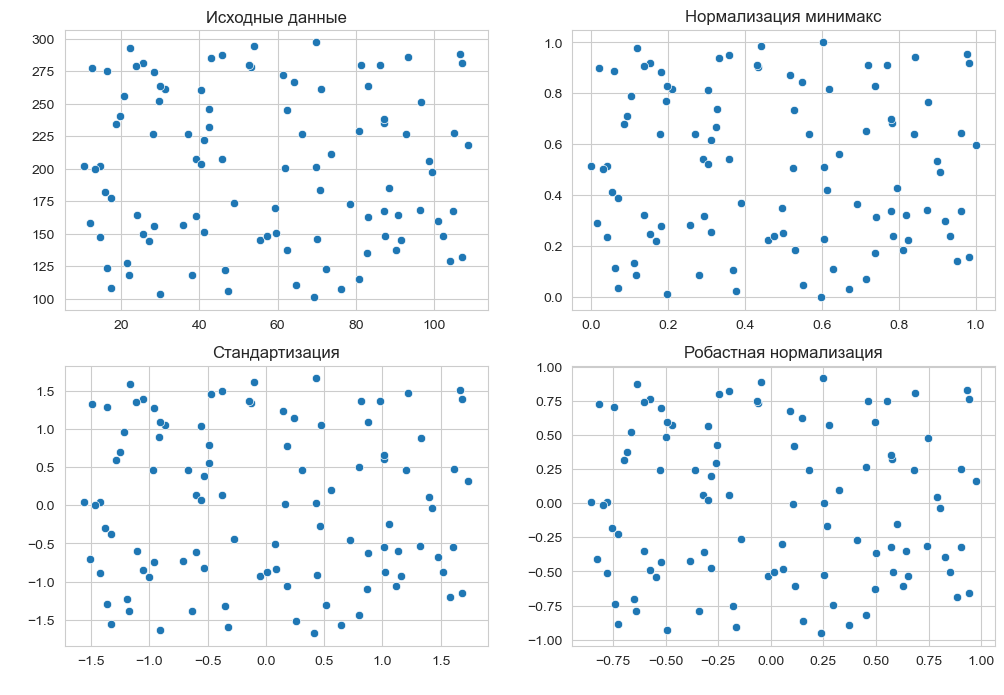

In [21]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))

ax[0][0].set_title('Исходные данные')
ax[0][0].set_xlabel(' ')
ax[0][0].set_ylabel(' ')
ax[0][1].set_title('Нормализация минимакс')
ax[0][1].set_xlabel(' ')
ax[0][1].set_ylabel(' ')
ax[1][0].set_title('Стандартизация')
ax[1][0].set_xlabel(' ')
ax[1][0].set_ylabel(' ')
ax[1][1].set_title('Робастная нормализация')
ax[1][1].set_xlabel(' ')
ax[1][1].set_ylabel(' ')

sns.scatterplot(data=df, x='x1', y='x2', ax=ax[0, 0])
sns.scatterplot(data=df_min_max_manual, x='x1', y='x2', ax=ax[0, 1])
sns.scatterplot(data=df_stand_manual, x='x1', y='x2', ax=ax[1, 0])
sns.scatterplot(data=df_robust_manual, x='x1', y='x2', ax=ax[1, 1])

plt.show()

А облако — то же самое. Точки — те же. Кто был соседом — остался соседом. Кто был выбросом — остался выбросом.

Это важнейшее свойство: все линейные преобразования сохраняют структуру данных. Они меняют только метки на осях и масштаб, но не взаимное расположение объектов в пространстве признаков.

## § 2. Регрессия с предварительной нормализацией

Мы уже разобрали три вида нормализации. Теперь пришло время задать себе самый важный вопрос: а нужно ли это всё вообще?

Чтобы ответить на этот вопрос, мы проведём эксперимент. У нас есть датасет `skill_spring.csv`, который описывает студентов платформы онлайн-образования. Мы попробуем предсказать их финальную оценку — и посмотрим, как поведёт себя линейная регрессия в разных условиях.

Начнём с чтения данных и baseline-модели.

In [22]:
df = pd.read_csv('data/skill_spring.csv')
print(df)

     hours_per_week  break_freq  sessions_per_week  task_completion_rate  \
0          4.692681    0.686871                  8              0.855398   
1         30.101214    0.238177                  2              0.961234   
2         13.167457    0.791471                  8              0.730651   
3          9.129426    0.929982                  9              0.686953   
4          2.000000    0.897496                 10              0.914914   
..              ...         ...                ...                   ...   
995        2.000000    0.240745                  7              0.551471   
996       24.926998    0.395249                 10              0.925255   
997        2.000000    0.591008                  7              0.745637   
998       30.004907    0.449099                 16              0.818514   
999        5.906010    0.373553                  7              0.727188   

     forum_posts  prev_course_score  device_type  is_weekend_learner  \
0             2

#### Контекст

Платформа онлайн-образования «SkillSpring» хочет повысить удержание студентов на курсах по Data Science. Было замечено, что студенты, которые проводят на платформе больше времени, но при этом делают перерывы между занятиями, показывают лучшие результаты в финальных проектах. Однако точной зависимости между паттернами обучения и финальной оценкой пока нет.

#### Датасет

- hours_per_week — количество часов, проведённых на платформе за неделю (2–40) (float),
- break_freq — средняя частота перерывов (количество перерывов за 1 час занятий) (0.1–3.0) (float),
- sessions_per_week — число сессий (входов) в неделю (1–25) (int),
- task_completion_rate — доля вовремя сданных заданий (0.0–1.0) (float),
- forum_posts — количество постов на форуме за неделю (0–50) (int),
- prev_course_score — средний балл за предыдущие курсы (30–100) (float),
- device_type — тип устройства: 0 — ПК, 1 — планшет, 2 — смартфон (int),
- is_weekend_learner — учится ли преимущественно в выходные (0 — нет, 1 — да) (int).

#### Таргет

- final_project_score — оценка за финальный проект (0–100) (float).

#### Бизнес-задача

Понимать, какие факторы наиболее сильно влияют на финальную оценку, чтобы рекомендовать студентам оптимальные паттерны обучения и повысить качество образования (и, как следствие, удержание на платформе).

Что мы видим? Наши признаки — это часы в неделю, частота перерывов, количество сессий, выполнение заданий, активность на форуме, прошлые баллы, тип устройства и признак того, учится ли студент по выходным. Таргет — заветный балл за финальный проект.

Обучаем простую линейную регрессию на сырых данных.

In [23]:
X = df.drop(columns='final_project_score')
y = df['final_project_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2_baseline = r2_score(y_test, y_pred)
print('r2_baseline =', r2_baseline)

r2_baseline = 0.8494365990206918


Получаем R<sup>2</sup> = 0.8494. Неплохо. Но хочется верить, что нормализация сделает ещё лучше. Мы же старались, формулы учили, квартили считали — не зря же!

Давайте попробуем `MinMaxScaler`.

In [24]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_min_max = scaler.transform(X_train)
X_test_min_max = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_min_max, y_train)

y_pred = model.predict(X_test_min_max)

r2_min_max = r2_score(y_test, y_pred)
print('r2_min_max =', r2_min_max)

r2_min_max = 0.8494365990206914


То же самое. Может, стандартизация?

In [25]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_min_max = scaler.transform(X_train)
X_test_min_max = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_min_max, y_train)

y_pred = model.predict(X_test_min_max)

r2_stand = r2_score(y_test, y_pred)
print('r2_stand =', r2_stand)

r2_stand = 0.8494365990206915


Уже начинает зарождаться подозрение.


RobustScaler?

In [26]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train_min_max = scaler.transform(X_train)
X_test_min_max = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_min_max, y_train)

y_pred = model.predict(X_test_min_max)

r2_robust = r2_score(y_test, y_pred)
print('r2_robust =', r2_robust)

r2_robust = 0.8494365990206914


Всё. Четыре попытки. Четыре разных способа преобразования данных. Один и тот же результат с точностью до машинной погрешности в 15-м знаке.


Что происходит?


А происходит вот что. Линейная регрессия — это, как ни крути, линейная модель. Она ищет коэффициенты w
 такие, чтобы y = wX + b как можно точнее предсказывало целевую переменную. Когда мы применяем нормализацию, мы фактически домножаем каждый признак на константу и прибавляем к нему константу. Это линейное преобразование.


А линейная функция от линейной функции — это снова линейная функция. Просто с другими коэффициентами. Линейная регрессия, бедняжка, даже не заметит ваших стараний: она просто пересчитает веса, скомпенсировав все сдвиги и растяжения. Вы ей хоть в метрах подайте данные, хоть в километрах, хоть в попугаях — она подстроится.


Вот доказательство. Посмотрите на веса модели в каждом случае (кстати, советую вывести `model.coef_` после каждого эксперимента): они будут разными. А предсказания — одинаковыми. Модель адаптируется к масштабу данных. Ей всё равно.


Это не значит, что нормализация бесполезна вообще. Это значит, что она бесполезна для линейной регрессии. А вот для других моделей…

### § 3. Бинарная классификация с предварительной нормализацией

Итак, коллеги (обращаюсь ко всем, кто еще не закрыл ноутбук и не ушел пить чай), мы только что убедились, что линейная регрессия абсолютно равнодушна к нормализации. Она как старый мудрый философ — ее не волнует, в каких единицах измерения вы подаете данные, она просто подкрутит коэффициенты и выдаст тот же результат.

Но теперь мы берем другую модель. Модель, которая не является линейной. Модель, которая принимает решения на основе расстояний между точками. Модель, которая — и это важно — не умеет абстрагироваться от масштаба признаков.

Я говорю, конечно же, о методе ближайших соседей.

Давайте посмотрим на реальный пример. Откроем датасет `quick_bite.csv` — это данные сервиса доставки еды, где мы пытаемся предсказать, оставит ли клиент чаевые.

In [27]:
df = pd.read_csv('data/quick_bite.csv')
print(df)

      delivery_time_min  order_amount  distance_km  courier_rating  \
0                    51    474.570822     3.318117        4.246345   
1                    42    618.774349     0.500000        3.148857   
2                    54    447.550795    17.960831        4.007384   
3                    70    570.218280     3.649164        3.365250   
4                    41    258.060142     4.762003        4.147950   
...                 ...           ...          ...             ...   
1995                 61    674.673446     3.441456        4.010056   
1996                 44    235.354783     0.841162        3.060993   
1997                 34    566.711920     1.010109        3.263621   
1998                 42   1512.756977     2.271026        4.773179   
1999                 35    796.577118     2.832019        4.503360   

      courier_experience  is_weekend  is_rain  num_items  tip  
0                     17           0        1          5    0  
1                     16       

#### Контекст

Служба доставки готовой еды «QuickBite» хочет повысить вероятность того, что клиент оставит чаевые курьеру. Было замечено, что некоторые факторы (время доставки, погода, сумма заказа) влияют на решение клиента, но точная зависимость неизвестна. Задача — построить модель, которая предскажет, оставит ли клиент чаевые.

#### Датасет

- delivery_time_min — время доставки от момента заказа до получения (10–120 мин) (int),
- order_amount — сумма заказа (200–3000 руб) (float),
- distance_km — расстояние от ресторана до клиента (0.5–20.0 км) (float),
- courier_rating — рейтинг курьера (3.0–5.0) (float),
- courier_experience — стаж курьера (0–36 мес) (int),
- is_weekend — выходной ли день (0 — будни, 1 — выходной) (int),
- is_rain — идёт ли дождь (0 — нет, 1 — да) (int),
- num_items — количество позиций в заказе (1–10) (int).

#### Таргет

- tip — оставлены ли чаевые (0 — нет, 1 — да) (int).

#### Бизнес-задача

Понимать, какие факторы влияют на вероятность чаевых, чтобы мотивировать курьеров в нужных ситуациях (например, в дождь или при больших заказах) и повышать общее качество сервиса.

Обучаем k-NN на сырых данных. Получаем метрики, которые… ну, скажем так, не заставляют нас бежать и звонить маме, чтобы похвастаться.

In [28]:
X = df.drop(columns='tip')
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = KNeighborsClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_baseline = accuracy_score(y_test, y_pred)
print('accuracy_baseline =', accuracy_baseline)
precision_baseline = precision_score(y_test, y_pred)
print('precision_baseline =', precision_baseline)
recall_baseline = recall_score(y_test, y_pred)
print('recall_baseline =', recall_baseline)
f1_baseline = f1_score(y_test, y_pred)
print('f1_baseline =', f1_baseline)

accuracy_baseline = 0.668
precision_baseline = 0.7123745819397993
recall_baseline = 0.726962457337884
f1_baseline = 0.7195945945945945


Accuracy: 0.668. F1: 0.72. Работает. Но похоже на студента, который учил билеты всю ночь, но утром забыл половину. Неплохо, но могло быть лучше.

А теперь — фокус. Мы применяем `MinMaxScaler`. И смотрим на результат.

In [29]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_min_max = scaler.transform(X_train)
X_test_min_max = scaler.transform(X_test)

model = KNeighborsClassifier()
model.fit(X_train_min_max, y_train)

y_pred = model.predict(X_test_min_max)

accuracy_min_max = accuracy_score(y_test, y_pred)
print('accuracy_min_max =', accuracy_min_max)
precision_min_max = precision_score(y_test, y_pred)
print('precision_min_max =', precision_min_max)
recall_min_max = recall_score(y_test, y_pred)
print('recall_min_max =', recall_min_max)
f1_min_max = f1_score(y_test, y_pred)
print('f1_min_max =', f1_min_max)

accuracy_min_max = 0.874
precision_min_max = 0.8782894736842105
recall_min_max = 0.9112627986348123
f1_min_max = 0.8944723618090452


Accuracy подскакивает до 0.874. F1 — до 0.894. Прирост — больше 20 процентных пунктов. Коллеги, это уже не прирост. Это прорыв. 

Что произошло? Произошло вот что. kNN — это модель, основанная на расстояниях. Если у вас признак «сумма заказа» измеряется в тысячах рублей, а признак «количество позиций» — в штуках от 1 до 10, то без нормализации расстояние будет почти полностью определяться суммой заказа. Остальные признаки просто теряются на фоне гигантских чисел.

Нормализация приводит все признаки к сопоставимому масштабу. И внезапно оказывается, что количество позиций, дождь и рейтинг курьера — тоже важны. Кто бы мог подумать.

Пробуем `StandardScaler`.

In [30]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_min_max = scaler.transform(X_train)
X_test_min_max = scaler.transform(X_test)

model = KNeighborsClassifier()
model.fit(X_train_min_max, y_train)

y_pred = model.predict(X_test_min_max)

accuracy_stand = accuracy_score(y_test, y_pred)
print('accuracy_stand =', accuracy_stand)
precision_stand = precision_score(y_test, y_pred)
print('precision_stand =', precision_stand)
recall_stand = recall_score(y_test, y_pred)
print('recall_stand =', recall_stand)
f1_stand = f1_score(y_test, y_pred)
print('f1_stand =', f1_stand)

accuracy_stand = 0.892
precision_stand = 0.9134948096885813
recall_stand = 0.9010238907849829
f1_stand = 0.9072164948453608


Accuracy: 0.892. F1: 0.907. Еще лучше. Стандартизация сработала эффективнее минимакса — потому что она не просто сжимает данные в отрезок [0,1], а приводит их к распределению с нулевым средним и единичной дисперсией. Это особенно полезно, если в данных есть выбросы — хотя здесь, видимо, выбросов было немного, раз `RobustScaler` дал чуть меньше.

Пробуем `RobustScaler`.

In [31]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train_min_max = scaler.transform(X_train)
X_test_min_max = scaler.transform(X_test)

model = KNeighborsClassifier()
model.fit(X_train_min_max, y_train)

y_pred = model.predict(X_test_min_max)

accuracy_robust = accuracy_score(y_test, y_pred)
print('accuracy_robust =', accuracy_robust)
precision_robust = precision_score(y_test, y_pred)
print('precision_robust =', precision_robust)
recall_robust = recall_score(y_test, y_pred)
print('recall_robust =', recall_robust)
f1_robust = f1_score(y_test, y_pred)
print('f1_robust =', f1_robust)

accuracy_robust = 0.886
precision_robust = 0.906896551724138
recall_robust = 0.8976109215017065
f1_robust = 0.9022298456260722


Accuracy: 0.886. F1: 0.902. Тоже отлично, но золото берет `StandardScaler`.

Теперь, коллеги, давайте зафиксируем главный вывод этого параграфа. Я повторю его медленно, чтобы вы успели записать, даже если пишете огрызком карандаша на полях тетради:

**Если ваша модель нелинейна — нормализация не просто возможна, она необходима.**

Это важно. Если вы используете kNN, SVM с нелинейным ядром, нейронные сети или даже дерево решений (хотя деревьям в целом плевать на масштаб, но для некоторых реализаций это важно), — **вы обязаны попробовать нормализацию**.

И еще один важный момент, который я как старый циничный преподаватель обязан вам сказать: нормализация — это не волшебная таблетка. Она не гарантирует улучшения. Иногда она может даже ухудшить результат — например, если в данных много шума или если распределение признаков изначально не подходит под выбранный метод.

Но в большинстве случаев — да, она работает. И работает хорошо.

Запомните: вы можете быть гением инженерии признаков, вы можете строить ансамбли из ста моделей, вы можете настраивать гиперпараметры неделями — но если вы забыли нормализовать данные до подачи их в kNN, то вы выбрасываете деньги на ветер. И время.

## § 4. Кодирование категориальных данных

Категориальные признаки — это номинальные (цвет глаз, город) или ординальные (должность, уровень образования) данные, которые модель не умеет обрабатывать в сыром виде. Большинство моделей машинного обучения оперируют числами. Кошка — не число. Москва — не число. Старший лейтенант — тоже (хотя тут уже есть порядок, потому что предыдущим является лейтенант, а следующим станет капитан).

Смотрите, какие подходы существуют. Я разобью их на три группы: простое кодирование, продвинутое и экзотическое.

### 4.1. Простое кодирование

А почему, собственно, простое? Назовём так методы, которые не подглядывают в целевую переменную. Работают исключительно с матрицей признаков X, не заглядывая в y. Благородная бедность или принципиальная слепота — решайте сами. Хотя слово «простое» здесь обманчиво: до некоторых из этих методов попробуй ещё додумайся. Тот же One Hot Encoding, при всём его изяществе, — продукт отнюдь не тривиальной мысли.


#### 4.1.1. Label Encoding (порядковое кодирование)

Самый прямолинейный метод. Идея проста до безобразия: берём категории и нумеруем их. Раз, два, три — и готово. Никакой магии, чистая бюрократия.


Возьмём игрушечный датасет. Точнее — датафрейм. 

In [32]:
df = pd.DataFrame()

df['Имя'] = ['Катя', 'Петя', 'Лена', 'Костя', 'Слава', 'Катя', 'Таня', 'Леша', 'Леша', 'Аня']
df['Образование'] = ['Высшее', 'Ученая степень', 'Высшее', 'Среднее', 'Среднее', 'Среднее', 
                     'Высшее', 'Среднее', 'Ученая степень', 'Высшее',]
print(df)

     Имя     Образование
0   Катя          Высшее
1   Петя  Ученая степень
2   Лена          Высшее
3  Костя         Среднее
4  Слава         Среднее
5   Катя         Среднее
6   Таня          Высшее
7   Леша         Среднее
8   Леша  Ученая степень
9    Аня          Высшее


Вот такая компания. Хотим превратить «Образование» в числа. Нумеруем — естественно, с учётом порядка: среднее, высшее, учёная степень. Не потому, что мы снобы, а потому что ординальность здесь очевидна.

In [33]:
def encoding(row):
    if row['Образование'] == 'Среднее':
        return 0
    elif row['Образование'] == 'Высшее':
        return 1
    elif row['Образование'] == 'Ученая степень':
        return 2
    else:
        return -1
    
df['Образование'] = df.apply(encoding, axis=1)
print(df)

     Имя  Образование
0   Катя            1
1   Петя            2
2   Лена            1
3  Костя            0
4  Слава            0
5   Катя            0
6   Таня            1
7   Леша            0
8   Леша            2
9    Аня            1


Плюсы метода — очевидны: простота реализации, сохранение размерности (был один столбец — один и остался), интуитивная понятность. Если в категориях есть естественный порядок — метод работает идеально. Более того — он этот порядок явно сообщает модели, что для некоторых алгоритмов (например, для деревьев, которые умеют улавливать монотонные зависимости) может быть критически важно.

Минусы — тоже на поверхности. Если порядка нет, мы его навязываем. А модель — существо доверчивое. Она видит числа и думает: «ага, 2 больше 1, значит, "Учёная степень" как-то больше, чем "Высшее", не просто другая, а именно больше». Для цвета глаз, городов, марок автомобилей это катастрофа. Синий не больше зелёного, Москва не больше Воронежа (ну, географически — больше, но мы сейчас о другом).

Ещё один нюанс: что именно означают числа 0, 1 и 2? Для линейной регрессии это создаёт неявное предположение о равных расстояниях между соседними значениями. Разница между «Средним» и «Высшим» такая же, как между «Высшим» и «Учёной степенью»? Сомнительно, хотя в жизни бывает и не такое.

Применяют ли Label Encoding часто? Отвечу честно: реже, чем One Hot Encoding, но чаще, чем о нём говорят. В задачах, где признаки заведомо ординальны (уровень образования, воинские звания, класс гостиницы, размер пиццы), — это первый и самый естественный выбор. А ещё он бывает полезен, когда число категорий зашкаливает, и One Hot Encoding грозит превратить датафрейм в простыню из ста колонок. Но об этом — чуть позже.

#### 4.1.2. One Hot Encoding (как по-русски?)

А по-русски — никак. Язык сопротивляется. Можно, конечно, сказать «кодирование с одним активным состоянием» или «индикаторное кодирование», но это примерно как перевести «sushi» как «сырая рыба на комочке риса». Формально верно, но никто так не говорит. Поэтому — One Hot Encoding. Смиритесь.

Идея, впрочем, проста и красива. Вместо одного столбца с k категориями мы создаём k бинарных столбцов. Каждый столбец отвечает на вопрос: «Принадлежит ли объект к данной категории?» Ответ — да (1) или нет (0). Для каждого объекта ровно один столбец содержит единицу — тот самый «горячий» бит. Отсюда и название.

Разберём на том же игрушечном датафрейме. Будем действовать медленно и педантично, чтобы прочувствовать механику.

In [34]:
df = pd.DataFrame()

df['Имя'] = ['Катя', 'Петя', 'Лена', 'Костя', 'Слава', 'Катя', 'Таня', 'Леша', 'Леша', 'Аня']
df['Образование'] = ['Высшее', 'Ученая степень', 'Высшее', 'Среднее', 'Среднее', 'Среднее', 
                     'Высшее', 'Среднее', 'Ученая степень', 'Высшее',]
print(df)

     Имя     Образование
0   Катя          Высшее
1   Петя  Ученая степень
2   Лена          Высшее
3  Костя         Среднее
4  Слава         Среднее
5   Катя         Среднее
6   Таня          Высшее
7   Леша         Среднее
8   Леша  Ученая степень
9    Аня          Высшее


Теперь шаг за шагом.

Шаг первый: столбец для среднего образования.

In [35]:
def encoding_secondary(row):
    if row['Образование'] == 'Среднее':
        return 1
    else:
        return 0
    
df['Образование: среднее'] = df.apply(encoding_secondary, axis=1)
print(df)

     Имя     Образование  Образование: среднее
0   Катя          Высшее                     0
1   Петя  Ученая степень                     0
2   Лена          Высшее                     0
3  Костя         Среднее                     1
4  Слава         Среднее                     1
5   Катя         Среднее                     1
6   Таня          Высшее                     0
7   Леша         Среднее                     1
8   Леша  Ученая степень                     0
9    Аня          Высшее                     0


Видите? Для Кости, Славы, Кати и Леши — единица, для всех остальных — ноль. Простейшая логика.


Шаг второй: столбец для высшего образования. Появляется паттерн.

In [36]:
def encoding_higher(row):
    if row['Образование'] == 'Высшее':
        return 1
    else:
        return 0

df['Образование: высшее'] = df.apply(encoding_higher, axis=1)
print(df)

     Имя     Образование  Образование: среднее  Образование: высшее
0   Катя          Высшее                     0                    1
1   Петя  Ученая степень                     0                    0
2   Лена          Высшее                     0                    1
3  Костя         Среднее                     1                    0
4  Слава         Среднее                     1                    0
5   Катя         Среднее                     1                    0
6   Таня          Высшее                     0                    1
7   Леша         Среднее                     1                    0
8   Леша  Ученая степень                     0                    0
9    Аня          Высшее                     0                    1


Шаг третий: столбец для учёной степени. Картина обретает полноту.

In [37]:
def encoding_PhD(row):
    if row['Образование'] == 'Ученая степень':
        return 1
    else:
        return 0

df['Образование: ученая степень'] = df.apply(encoding_PhD, axis=1)
print(df)

     Имя     Образование  Образование: среднее  Образование: высшее  \
0   Катя          Высшее                     0                    1   
1   Петя  Ученая степень                     0                    0   
2   Лена          Высшее                     0                    1   
3  Костя         Среднее                     1                    0   
4  Слава         Среднее                     1                    0   
5   Катя         Среднее                     1                    0   
6   Таня          Высшее                     0                    1   
7   Леша         Среднее                     1                    0   
8   Леша  Ученая степень                     0                    0   
9    Аня          Высшее                     0                    1   

   Образование: ученая степень  
0                            0  
1                            1  
2                            0  
3                            0  
4                            0  
5                   

Последний штрих: удаляем исходный столбец «Образование». Он выполнил свою миссию и может отправляться на покой.

In [38]:
df = df.drop(columns = ['Образование'])
print(df)

     Имя  Образование: среднее  Образование: высшее  \
0   Катя                     0                    1   
1   Петя                     0                    0   
2   Лена                     0                    1   
3  Костя                     1                    0   
4  Слава                     1                    0   
5   Катя                     1                    0   
6   Таня                     0                    1   
7   Леша                     1                    0   
8   Леша                     0                    0   
9    Аня                     0                    1   

   Образование: ученая степень  
0                            0  
1                            1  
2                            0  
3                            0  
4                            0  
5                            0  
6                            0  
7                            0  
8                            1  
9                            0  


Вот и всё. Перед нами — результат One Hot Encoding в ручном режиме. Три столбца вместо одного. Никакой магии.


Но писать такие функции для каждого категориального признака — занятие для мазохистов. К счастью, в pandas есть метод `get_dummies`, который делает всё за нас. И делает это красиво.

In [39]:
df = pd.DataFrame()

df['Имя'] = ['Катя', 'Петя', 'Лена', 'Костя', 'Слава', 'Катя', 'Таня', 'Леша', 'Леша', 'Аня']
df['Образование'] = ['Высшее', 'Ученая степень', 'Высшее', 'Среднее', 'Среднее', 'Среднее', 
                     'Высшее', 'Среднее', 'Ученая степень', 'Высшее',]

df = pd.get_dummies(df, columns=['Образование'])

print(df)

     Имя  Образование_Высшее  Образование_Среднее  Образование_Ученая степень
0   Катя                   1                    0                           0
1   Петя                   0                    0                           1
2   Лена                   1                    0                           0
3  Костя                   0                    1                           0
4  Слава                   0                    1                           0
5   Катя                   0                    1                           0
6   Таня                   1                    0                           0
7   Леша                   0                    1                           0
8   Леша                   0                    0                           1
9    Аня                   1                    0                           0


Изящно. Быстро. Безболезненно.

Теперь — о достоинствах и недостатках. Плюсы колоссальные. Метод не навязывает ложного порядка. Каждый бинарный столбец ортогонален остальным: «среднее» и «высшее» не больше и не меньше друг друга, они просто разные. Для линейных моделей — это вообще подарок, потому что каждый коэффициент будет отвечать строго за свою категорию.

Минусы, впрочем, тоже имеются, и о них надо говорить честно. Во-первых, размерность. Если у вас признак с сотней категорий — получите сотню столбцов. Для тысячи категорий — тысячу столбцов. При этом большинство ячеек будут заполнены нулями — матрица становится разреженной. Некоторые алгоритмы с этим справляются (например, методы на основе деревьев), а некоторые — начинают страдать.

Во-вторых, мультиколлинеарность. Обратите внимание: если у объекта единица в столбце «Высшее», то в столбцах «Среднее» и «Ученая степень» гарантированно нули. Три столбца линейно зависимы: сумма всех трёх для любого объекта равна единице. Для регрессии это проблема — классическая dummy variable trap (ловушка фиктивной переменной). Решается просто: выкидываем один из столбцов, превращая k бинарных признаков в k-1. В pandas это делается параметром `drop_first=True`. Тогда отсутствие единиц в оставшихся столбцах будет однозначно указывать на ту категорию, которую мы удалили. Но если вы используете регуляризацию (а вопросам регуляризации будет посвящена наша следующая лекция) — этот фокус, вообще-то, и не обязателен.

И тем не менее — One Hot Encoding используют повсеместно. Это правда. Если вы не знаете, какой метод выбрать — выбирайте этот. Ошибетесь редко. Для большинства практических задач, где число категорий измеряется десятками, а не тысячами, — это золотой стандарт.

### 4.2. Продвинутое кодирование. Target Encoding

А почему оно, собственно, продвинутое? — спросите вы, и будете совершенно правы. Ответ элегантен и прост: потому что оно апеллирует не только к левой части задачи прогнозирования, но и к правой. В отличие от наивных методов, которые мы разобрали в предыдущем разделе, Target Encoding не притворяется, что знает только X. Он заглядывает в y — и это, замечу я вам с легкой профессорской усмешкой, сразу переводит его в высшую лигу.

Давайте схитрим. Кто сказал, что ранжирование категорий может осуществляться только порядково — целыми числами, словно мы нумеруем дома по улице? А что, если нам позволить дробное ранжирование? Но тогда немедленно возникает вопрос — относительно чего мы будем встраивать наши ранги? И ответ, как это часто бывает в науке, одновременно очевиден и гениален: относительно той самой целевой функции, ради которой мы и затеяли кодирование категориального признака. Давайте присвоим каждой категории не произвольный номер, а среднее значение таргета. Просто. Изящно. И, как вы увидите через минуту, слегка провокационно по отношению к нашему общественному устройству.

Допустим, в нашем игрушечном примере про степень образованности мы хотим предсказывать зарплату. Кто больше получает — тот, выходит, и «образованнее» с точки зрения нашей модели. Добавим ещё один столбец в наш датафрейм:

In [40]:
df = pd.DataFrame()

df['Имя'] = ['Катя', 'Петя', 'Лена', 'Костя', 'Слава', 'Катя', 'Таня', 'Леша', 'Леша', 'Аня']
df['Образование'] = ['Высшее', 'Ученая степень', 'Высшее', 'Среднее', 'Среднее', 'Среднее', 
                     'Высшее', 'Среднее', 'Ученая степень', 'Высшее',]
df['Зарплата'] = [65000, 47000, 59000, 92000, 112000, 103000, 69000, 94000, 39000, 57000]

print(df)

     Имя     Образование  Зарплата
0   Катя          Высшее     65000
1   Петя  Ученая степень     47000
2   Лена          Высшее     59000
3  Костя         Среднее     92000
4  Слава         Среднее    112000
5   Катя         Среднее    103000
6   Таня          Высшее     69000
7   Леша         Среднее     94000
8   Леша  Ученая степень     39000
9    Аня          Высшее     57000


А теперь смотри́те, что мы делаем. Мы отказываемся от условностей вроде «ученая степень — это 2, а среднее — это 0». Вместо этого мы говорим: «Образование кодируется средней величиной зарплаты, которую получают люди с тем или иным уровнем образованности». Сухо? Сухо. Но элегантно. Вот код:

In [41]:
def encoding(row):
    if row['Образование'] == 'Среднее':
        d = df.loc[df['Образование'] == 'Среднее']
        return d['Зарплата'].mean()
    elif row['Образование'] == 'Высшее':
        d = df.loc[df['Образование'] == 'Высшее']
        return d['Зарплата'].mean()
    elif row['Образование'] == 'Ученая степень':
        d = df.loc[df['Образование'] == 'Ученая степень']
        return d['Зарплата'].mean()
    else:
        return -1
    
df['Образование'] = df.apply(encoding, axis=1)
print(df)

     Имя  Образование  Зарплата
0   Катя      62500.0     65000
1   Петя      43000.0     47000
2   Лена      62500.0     59000
3  Костя     100250.0     92000
4  Слава     100250.0    112000
5   Катя     100250.0    103000
6   Таня      62500.0     69000
7   Леша     100250.0     94000
8   Леша      43000.0     39000
9    Аня      62500.0     57000


Взгляните на эту таблицу ещё раз. Что мы видим? Среднее образование — средняя зарплата около ста тысяч. Высшее — шестьдесят две с половиной. Ученая степень — и вовсе сорок три. 

В этом месте хочется сделать короткую паузу, оглядывая аудиторию и позволить себе маленькое лирическое отступление — этакий почти чеховский вздох: «Если ты такой умный, то почему ты такой бедный?». (Аудитория обычно оживляется: кто-то нервно смеётся, кто-то задумывается о смене карьерной траектории.) Но — отставить лирику. Возвращаемся к нашему методу. Какие у этого подхода плюсы и минусы? Я перечислю — кратко и по существу.

Плюсы. Во-первых, он невероятно информативен: категория получает не абстрактный номер, а величину, непосредственно связанную с задачей прогнозирования. Во-вторых, он не раздувает размерность: сколько бы ни было категорий — на выходе у вас всегда один столбец. И в-третьих, он интуитивно понятен: любой аналитик, взглянув на эти цифры, мгновенно понимает, что к чему.

Минусы. Самый главный и коварный — утечка данных. Если мы не разделим выборку перед кодированием, модель увидит таргет тех же строк, которые потом будет предсказывать — и радостно переобучится. Второй минус — чувствительность к выбросам. Один человек с зарплатой в миллион способен испортить всё кодирование для целой категории. Третий — плохая работа с редкими категориями, где среднее считается по трём наблюдениям и обладает точностью предсказания погоды на Марсе.

И тем не менее, метод живёт, процветает и обрастает модификациями. В следующем подразделе — про экзотику — я упомяну и ту, что получила за свою изобретательность премию.

### 4.3. Экзотическое кодирование

Ваш уставший лектор слегка оживляется. Потому что дальше пойдёт то, что не столько нужно в боевом применении, сколько то, о чем приятно поболтать  за ужином с коллегами — блеснуть эрудицией и получить порцию уважительных кивков. 

Итак, экзотика. Вот она, перед вами, во всей своей странной красе.

**Frequency Encoding.** Замена категории на частоту её встречаемости в выборке. Просто и элегантно. Если какая-то категория встречается в ваших данных 500 раз, а другая — всего 3, то их числовые представления различаются на два порядка — и модель это почувствует. Работает, если частотность сама по себе важна для предсказания. Например, если вы анализируете города по числу заказов и хотите, чтобы модель понимала: Москва — это «много», а Сызрань — «мало». Но если частотность не связана с таргетом — метод бесполезен.

**Binary Encoding.** Комбинация хеширования и бинарных признаков. Сначала категория нумеруется — как в Label Encoding. Потом её номер переводится в бинарную запись — и каждый бит становится отдельным признаком. Звучит сложнее, чем выглядит. Скажем, категория «Высшее» получила номер 1 — бинарная запись 001. Категория «Среднее» — номер 0 — запись 000. «Ученая степень» — номер 2 — запись 010. Вместо трёх колонок при One Hot — две колонки битов. Позволяет сократить число признаков по сравнению с One Hot. Метод хорош, но в реальной жизни я встречал его реже, чем хотелось бы. Видимо, людям лень думать в двоичной системе.

**CatBoost (он же Ordered Target Statistics).** А вот это — современная реализация Target Encoding, которую используют в библиотеке CatBoost. Если вы думаете, что Target Encoding из раздела 4.2 — это вершина эволюции, вы ошибаетесь. CatBoost пошёл дальше. Он учитывает порядок объектов и историю — то есть кодирует каждую категорию, глядя не на все данные разом (это было бы жульничеством — утечка данных, помните?), а последовательно, по мере поступления объектов. И делает это так хитро, что его авторы — внимание, молодые люди! — получили за эту идею премию. Если вы когда-нибудь будете писать диссертацию по машинному обучению — имейте в виду: хорошая идея по кодированию категорий может принести вам не только ученую степень, но и славу. Или хотя бы премию.

**Feature Hashing (или хеширование признаков).** Категория хешируется в фиксированное число бит, и каждый из них становится признаком. Гениальность метода в том, что он позволяет вообще не хранить словарь категорий. Вообще. Никакого списка уникальных значений, никакой памяти — только хеш-функция и фиксированное число выходных битов. Минус — коллизии. Разные категории могут попасть в один бит, и модель не сможет их различить. Но, как говорит мой опыт, иногда этим можно пренебречь — особенно если число категорий значительно меньше числа бит. А иногда коллизии даже полезны: они работают как регуляризация, не давая модели слишком тонко чувствовать разницу между похожими категориями.

И последнее. 

Параграф о кодировании категориальных данных подходит к концу. Если вы вынесли отсюда только одну мысль — пусть она будет такой: кодирование категорий — это не скучная рутина, которую можно отдать стажёру. Это искусство. Выбор метода кодирования способен изменить качество модели сильнее, чем подбор гиперпараметров. Он способен превратить мусорные данные в золото — или, наоборот, убить отличный датасет неверным выбором.

Выбирайте с умом. И помните: хороший дата-саентист отличается от плохого не количеством методов, которые он знает, а умением выбрать правильный.

## § 5. Регрессия с предварительным кодированием

Мы разберем три способа кодирования: Label Encoding, One Hot Encoding и Target Encoding. Baseline-модель без предварительного кодирования здесь никак не может получиться — это понятно. Поэтому говорить, что за счет кодирования мы улучшаем baseline — это неправильно. Мы не улучшаем baseline, мы приводим данные к виду, когда модель вообще возможна. 

Допустим, у нас есть какой-то датасет. К каким-то признакам мы можем применить Label Encoding, к другим — One Hot Encoding, к третьим — Targrt Encoding. Но даже чисто комбинаторно — получается слишком много способов кодирования всего корпуса предикторов. Как вы думаете, коллеги: есть ли какая-нибудь разумная рекомендация по способам кодирования? Или единственный совет — перебирайте все варианты и выбирайте те, у которых скор выше?

Ответ в том, что перебирать все комбинации — это для тех, у кого времени вагон, а кластеры гудят от безделья. В реальном мире, коллеги, мы не перебираем — мы думаем. А реальная рекомендация —  **начните с самого простого**. Label Encoding для ординальных признаков, One Hot — для номинальных с небольшим числом категорий, Target — для всего остального. Если видите, что модель плачет, — усложняйте. Если модель улыбается — оставьте как есть.

Давайте приступим к работк. Грузим датасет и смотрим на признаки.

In [42]:
df = pd.read_csv('data/house_in_window.csv')
print(df)

                district wall_type    street  price_per_sqm
0                Окраины    кирпич   Улица_8           98.0
1     Исторический центр    кирпич  Улица_35          152.8
2                Окраины   монолит  Улица_39           59.4
3                Окраины    панель  Улица_23           40.0
4     Исторический центр   монолит  Улица_47          163.0
...                  ...       ...       ...            ...
4995  Исторический центр   монолит  Улица_33          187.8
4996               Центр    кирпич  Улица_39          153.0
4997             Окраины   монолит  Улица_16           64.6
4998               Центр   монолит  Улица_28          102.7
4999  Исторический центр    панель  Улица_49          114.5

[5000 rows x 4 columns]


#### Контекст

Сеть агентств недвижимости «Дом в Окне» (HouseInWindow) хочет разработать модель автоматической оценки рыночной стоимости квартир. Агенты тратят много времени на ручную оценку, а клиенты жалуются на субъективность. Нужна объективная, воспроизводимая модель, которая предсказывает цену квадратного метра на основе характеристик квартиры.

#### Датасет

- district — район города (категориальный, 3 уникальных значения: Исторический центр, Центр, Окраины) (object).
- wall_type — тип стен (категориальный, 4 значения: кирпич, панель, монолит, дерево) (object).
- street — название улицы (категориальный, ~65 уникальных значений) (object).

#### Таргет

- price_per_sqm — цена квадратного метра в тысячах рублей (float, диапазон 40–280).

#### Бизнес-задача

Предсказывать `price_per_sqm` — чтобы автоматизировать оценку квартир, снизить влияние субъективного фактора и сократить время работы агента.

Целевая функция — цена за квадратный метр: классический float, с которым не надо танцевать шаманские пляски. А вот все предикторы — категориальные. Неприятно? Ну, могло быть хуже — например, JSON с пропусками.

Итак, перед нами три предиктора: район, материал стен и улица. Начнем с района. У района всего три возможных значения, и они — о чудо! — отлично ложатся на порядок. В историческом центре квартиры самые дорогие, на окраинах — самые дешевые, а географический центр — между ними. Это значит, что мы можем применить Label Encoding (он же порядковое кодирование), не опасаясь, что вносим в модель ложную метрику. 

Пишем код:

In [43]:
def encoding(row):
    if row['district'] == 'Окраины':
        return 0
    elif row['district'] == 'Центр':
        return 1
    else:
        return 2
    
df['district'] = df.apply(encoding, axis=1)
print(df)

      district wall_type    street  price_per_sqm
0            0    кирпич   Улица_8           98.0
1            2    кирпич  Улица_35          152.8
2            0   монолит  Улица_39           59.4
3            0    панель  Улица_23           40.0
4            2   монолит  Улица_47          163.0
...        ...       ...       ...            ...
4995         2   монолит  Улица_33          187.8
4996         1    кирпич  Улица_39          153.0
4997         0   монолит  Улица_16           64.6
4998         1   монолит  Улица_28          102.7
4999         2    панель  Улица_49          114.5

[5000 rows x 4 columns]


Районы превратились в циферки. Поздравляю: мы сделали ровно то, чего так ждет любая регрессия, — подарили ей осмысленную числовую шкалу.


Идем дальше. Тип стен. У нас четыре категории: кирпич, панель, монолит, дерево. Очевидного порядка между ними нет — никто не скажет, «дерево меньше панели» в том смысле, в каком «окраина меньше центра». Поэтому порядковое кодирование здесь неуместно. Выбираем One Hot Encoding. Не будем унижать себя ручным трудом — pandas справится лучше и быстрее:

In [44]:
df = pd.get_dummies(df, columns=['wall_type'])

print(df)

      district    street  price_per_sqm  wall_type_дерево  wall_type_кирпич  \
0            0   Улица_8           98.0                 0                 1   
1            2  Улица_35          152.8                 0                 1   
2            0  Улица_39           59.4                 0                 0   
3            0  Улица_23           40.0                 0                 0   
4            2  Улица_47          163.0                 0                 0   
...        ...       ...            ...               ...               ...   
4995         2  Улица_33          187.8                 0                 0   
4996         1  Улица_39          153.0                 0                 1   
4997         0  Улица_16           64.6                 0                 0   
4998         1  Улица_28          102.7                 0                 0   
4999         2  Улица_49          114.5                 0                 0   

      wall_type_монолит  wall_type_панель  
0      

Четыре бинарных столбца вместо одного. 

Наконец — улицы. Их много: примерно 65. Никакого осмысленного порядка тут нет и близко. One Hot Encoding породил бы 65 дополнительных столбцов — пока терпимо, но, как мы увидим позже, в условиях малых выборок это становится катастрофичным. А пока используем Target Encoding: заменим название каждой улицы на среднюю цену квадратного метра по ней. 

Вот так:

In [45]:
street_list = df['street'].unique()

def encoding(row):
    for street in street_list:
        if row['street'] == street:
            d = df.loc[df['street'] == street]
            return d['price_per_sqm'].mean()
        
df['street'] = df.apply(encoding, axis=1)
print(df)

      district      street  price_per_sqm  wall_type_дерево  wall_type_кирпич  \
0            0  128.982500           98.0                 0                 1   
1            2  119.451316          152.8                 0                 1   
2            0  136.282432           59.4                 0                 0   
3            0  107.123457           40.0                 0                 0   
4            2  114.105208          163.0                 0                 0   
...        ...         ...            ...               ...               ...   
4995         2  127.675294          187.8                 0                 0   
4996         1  136.282432          153.0                 0                 1   
4997         0  117.331707           64.6                 0                 0   
4998         1  123.944737          102.7                 0                 0   
4999         2  103.026506          114.5                 0                 0   

      wall_type_монолит  wa

Вот и всё. Закодировали улицы через цены. Изящно, компактно и — что важнее — осмысленно. Теперь все наши предикторы числовые. Можно наконец выдохнуть и решать регрессионную задачу.

Ну что же, джентльмены и леди, дело привычное. Берём подготовленный датасет, пишем код, запускаем линейную регрессию, выдыхаем:

In [46]:
X = df.drop(columns='price_per_sqm')
y = df['price_per_sqm']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print('r2 =', r2_baseline)

r2 = 0.8494365990206918


Скор очень достойный. Модель объясняет почти 85% дисперсии. Поздравьте себя — вы только что решили регрессионную задачу, применив сразу три разных подхода к кодированию.


Но давайте проведем небольшой следственный эксперимент. Чисто из академического любопытства, без которого в науке делать нечего. А что если… плюнуть на все эти рассуждения и применить One Hot Encoding ко всем категориальным предикторам разом? В одну строчку? Буквально:

In [47]:
df = pd.read_csv('data/house_in_window.csv')
df = pd.get_dummies(df, columns=['district', 'wall_type', 'street'])

X = df.drop(columns='price_per_sqm')
y = df['price_per_sqm']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)#, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print('r2 =', r2)

r2 = 0.8695115257352433


Вот так. Одна строка — и скор получился даже лучше нашего тщательно продуманного ансамбля методов. 0.87 против 0.85. 

И тут у вас, коллеги, должен зачесаться затылок. Потому что это правильный зуд. Возникает резонный вопрос: а зачем тогда были все эти муки? Три разных логики, ручное написание функций, обсуждение природы признаков — всё ради того, чтобы проиграть одной строчке из pandas?

Вопрос прекрасный, и я бы даже сказал — ключевой для этого параграфа. И ответ на него будет. Чуть позже. А пока — сохраните этот зуд в затылке и не чешите.

— Так зачем же мы мучились? — спросите вы, и будете правы. Позвольте ответить вопросом на вопрос: а если объектов мало?

Вот представьте: данных — кот наплакал. Мы радостно применяем One Hot Encoding ко всем категориальным признакам, и наш скромный датасет раздувается до неприличия. Количество столбцов становится сравнимо с количеством строк. А линейная регрессия, даром что проста и элегантна, в таких условиях начинает вести себя… скажем так, неадекватно. Модель идеально запоминает обучающую выборку, а на тестовой — выдает такое, что учебники переписывать впору. От ужаса.

Давайте проверим и убедимся, а чтобы нас не обвинили в подгоне результатов, проведем серию из десяти запусков и усредним скор (честность — наше кредо, джентльмены):

In [48]:
r2_list = []

for a in range(10):

    df = pd.read_csv('data/house_in_window.csv')

    df_loc = df.sample(frac= 0.05)

    df_loc = pd.get_dummies(df_loc, columns=['district', 'wall_type', 'street'])

    X = df_loc.drop(columns='price_per_sqm')
    y = df_loc['price_per_sqm']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    
    r2_list.append(r2)
    
print('r2_ave =', np.array(r2_list).mean())

r2_ave = -1.4337608950772136e+24


Ну что тут скажешь… Минус бесконечность. В глубоком, клиническом смысле. Хуже модели не бывает — это даже не «ничего не предсказывает», это какая-то математическая катастрофа. Вселенная схлопнулась, данные прокляты, можете расходиться.

А теперь — внимание, фокус. Условия те же: данных мало. Но мы применяем наш продуманный арсенал — Label Encoding для района, One Hot для типа стен, Target Encoding для улиц. Снова десять запусков, снова усредняем (честность помним, кредо соблюдаем):

In [49]:
r2_list = []

for a in range(10):
#     print(a)

    df = pd.read_csv('data/house_in_window.csv')

    def encoding(row):
        if row['district'] == 'Окраины':
            return 0
        elif row['district'] == 'Центр':
            return 1
        else:
            return 2

    df['district'] = df.apply(encoding, axis=1)

    df = pd.get_dummies(df, columns=['wall_type'])

    street_list = df['street'].unique()

    def encoding(row):
        for street in street_list:
            if row['street'] == street:
                d = df.loc[df['street'] == street]
                return d['price_per_sqm'].mean()

    df['street'] = df.apply(encoding, axis=1)


    X = df.drop(columns=['price_per_sqm'])
    y = df['price_per_sqm']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    r2_list.append(r2)
    
print('r2_ave =', np.array(r2_list).mean())

r2_ave = 0.85946270957191


Вот. Результат — тот же, что и был на полном датасете. Модель не рухнула, скор не улетел в отрицательную бесконечность, жизнь продолжается. В чем секрет? Всё просто: число столбцов выросло сущими пустяками — всего-то на три дополнительных колонки. Соотношение числа строк и числа столбцов осталось в пределах разумного, приличия соблюдены, линейная регрессия не впала в панику.

Мораль, друзья мои, незамысловата, но фундаментальна: думать о способе кодирования надо. One Hot Encoding — отличный инструмент, но это не молоток, которым можно забивать любые гвозди. Иногда гвозди слишком маленькие, а данных слишком мало — и тогда молоток уходит в минус бесконечность.

Думать — это вообще полезно. Я настаиваю.

## Домашнее задание

>#### Задание 1
Прочитайте файл `'bistro_bull.csv'`.

In [50]:
df = pd.read_csv('data/bistro_bull.csv')
df

,rating,cuisine_type,restaurant_name,avg_check,high_margin
0,Четыре звезды,итальянская,Горячий хлеб,2364,0
1,Три звезды,азиатская,Хлеб и масло,321,0
2,Одна звезда,итальянская,Кофе-Брейк,348,0
3,Пять звезд,итальянская,Пицца-Прайм,2247,1
4,Четыре звезды,фастфуд,Лапшичная,1615,0
...,...,...,...,...,...
19995,Три звезды,азиатская,Деловой ланч,336,0
19996,Три звезды,азиатская,Быстро и вкусно,1201,1
19997,Четыре звезды,фастфуд,Быстро и вкусно,639,0
19998,Три звезды,фастфуд,Кондитерская-Кофе,1517,0


#### Контекст

Сеть городских кафе быстрого питания «BistroBull» хочет понимать, почему одни заведения обладают высокой маржинальностью (больше 5%), а другие — низкий (меньше 5%). 

#### Датасет

- rating — рейтинг заведения от одной до пяти звезд (object),
- cuisine_type — тип кухни заведения (4 значения: «русская», «итальянская», «азиатская», «фастфуд») (object),
- restaurant_name — название бренда (50-100 уникальных значений: «У Егора», «Пирожок на углу», «БургерХаус» и т.д. У одного бренда может быть несколько заведений) (object), 
- avg_check — средний чек в заведении в рублях (int).

#### Таргет

- high_margin — маржинальность > 5% (1) или < 5% (0) (int).

#### Бизнес-задача

Построить бинарный классификатор, предсказывающий `high_margin`. Это позволит менеджменту «BistroBull» понять, за счёт чего заведение становится успешным: важнее ли звездность, или тип кухни, или «раскрученное» имя. 

>#### Задание 2
Проведите кодирование категориальных данных.

In [51]:
# Код

>#### Задание 3
Обучите бинарный классификатор на ближайших соседях и вычислите его метрики прогнозирования.

In [52]:
# Код

>#### Задание 4
Проведите нормализацию данных. Как нормализация влияет на метрики прогнозирования?

In [53]:
# Код